# **Cirrhosis**

# **Data Understanding**  
**Pemahaman data** merupakan tahap awal dalam proses *Knowledge Discovery in Databases (KDD)* atau *Data Mining*. Langkah ini bertujuan untuk mengeksplorasi, menyelidiki, dan menganalisis dataset agar dapat memahami struktur, isi, serta karakteristik data sebelum melakukan analisis lebih lanjut.  

Pemahaman data yang baik sangat penting karena berpengaruh terhadap keberhasilan seluruh proses *data mining*, termasuk tahap *data preparation*, *modeling*, dan *evaluation*.  

---
## **Tujuan Pemahaman Data**  
1. **Memahami Konteks Data** – Mengenali sumber data, makna setiap variabel, serta hubungan antarvariabel dalam dataset.  
2. **Mengidentifikasi Permasalahan dalam Data** – Menemukan *missing values*, *outliers*, *noise*, atau ketidakkonsistenan dalam data.  
3. **Menilai Kualitas Data** – Memastikan bahwa data memiliki tingkat akurasi, kelengkapan, dan relevansi yang cukup untuk dianalisis.  
4. **Menentukan Arah Analisis** – Berdasarkan pemahaman awal, dapat dirumuskan hipotesis serta teknik *data mining* yang sesuai.  

---
## **Tahapan dalam Memahami Data**  
Berikut adalah beberapa langkah dalam memahami data:



In [18]:
!pip install pymysql
!pip install pandas
!pip install psycopg2-binary
!pip install sqlalchemy
!pip install python-dotenv



Upload env:

In [20]:
from google.colab import files
uploaded = files.upload()

Saving cirrhosis.csv to cirrhosis.csv


- koneksikan database di aiven

In [21]:
import pandas as pd

# Ganti 'nama_file.csv' dengan nama file yang sudah di-upload
df = pd.read_csv('cirrhosis.csv')

# Lihat beberapa baris pertama untuk memastikan
print(df.head())


   ID  N_Days Status             Drug    Age Sex Ascites Hepatomegaly Spiders  \
0   1     400      D  D-penicillamine  21464   F       Y            Y       Y   
1   2    4500      C  D-penicillamine  20617   F       N            Y       Y   
2   3    1012      D  D-penicillamine  25594   M       N            N       N   
3   4    1925      D  D-penicillamine  19994   F       N            Y       Y   
4   5    1504     CL          Placebo  13918   F       N            Y       Y   

  Edema  Bilirubin  Cholesterol  Albumin  Copper  Alk_Phos    SGOT  \
0     Y       14.5        261.0     2.60   156.0    1718.0  137.95   
1     N        1.1        302.0     4.14    54.0    7394.8  113.52   
2     S        1.4        176.0     3.48   210.0     516.0   96.10   
3     S        1.8        244.0     2.54    64.0    6121.8   60.63   
4     N        3.4        279.0     3.53   143.0     671.0  113.15   

   Tryglicerides  Platelets  Prothrombin  Stage  
0          172.0      190.0         12.2  

### 2. **Profiling data**

Profiling data adalah langkah penting dalam memahami karakteristik dataset sebelum melakukan analisis lebih lanjut.

---
#### **Ringkasan variabel dalam dataset**

- Menampilkan Informasi Dataset

In [22]:
# Menampilkan informasi struktur DataFrame setelah penggabungan
print(df.info())  # Menampilkan jumlah baris, kolom, tipe data, dan jumlah nilai non-null di setiap kolom


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             418 non-null    int64  
 1   N_Days         418 non-null    int64  
 2   Status         418 non-null    object 
 3   Drug           312 non-null    object 
 4   Age            418 non-null    int64  
 5   Sex            418 non-null    object 
 6   Ascites        312 non-null    object 
 7   Hepatomegaly   312 non-null    object 
 8   Spiders        312 non-null    object 
 9   Edema          418 non-null    object 
 10  Bilirubin      418 non-null    float64
 11  Cholesterol    284 non-null    float64
 12  Albumin        418 non-null    float64
 13  Copper         310 non-null    float64
 14  Alk_Phos       312 non-null    float64
 15  SGOT           312 non-null    float64
 16  Tryglicerides  282 non-null    float64
 17  Platelets      407 non-null    float64
 18  Prothrombi

- Menampilkan Ringkasan Statistik untuk Variabel Numerik

In [28]:
# Menampilkan statistik deskriptif untuk semua kolom numerik, kecuali 'id'
print(df.drop(columns=['id']).describe())



            N_Days           Age   Bilirubin  Cholesterol     Albumin  \
count   418.000000    418.000000  418.000000   284.000000  418.000000   
mean   1917.782297  18533.351675    3.220813   369.510563    3.497440   
std    1104.672992   3815.845055    4.407506   231.944545    0.424972   
min      41.000000   9598.000000    0.300000   120.000000    1.960000   
25%    1092.750000  15644.500000    0.800000   249.500000    3.242500   
50%    1730.000000  18628.000000    1.400000   309.500000    3.530000   
75%    2613.500000  21272.500000    3.400000   400.000000    3.770000   
max    4795.000000  28650.000000   28.000000  1775.000000    4.640000   

           Copper      Alk_Phos        SGOT  Tryglicerides   Platelets  \
count  310.000000    312.000000  312.000000     282.000000  407.000000   
mean    97.648387   1982.655769  122.556346     124.702128  257.024570   
std     85.613920   2140.388824   56.699525      65.148639   98.325585   
min      4.000000    289.000000   26.350000   

---
- Menampilkan Statistik untuk Variabel Kategorikal

In [36]:
# Menampilkan jumlah sampel untuk setiap kategori di setiap kolom
for column in df.select_dtypes(include=['object', 'category']).columns:
    print(f"Distribusi untuk kolom '{column}':")
    print(df[column].value_counts())
    print()  # Baris kosong antara hasil


Distribusi untuk kolom 'Status':
Status
C     232
D     161
CL     25
Name: count, dtype: int64

Distribusi untuk kolom 'Drug':
Drug
D-penicillamine    158
Placebo            154
Name: count, dtype: int64

Distribusi untuk kolom 'Sex':
Sex
F    374
M     44
Name: count, dtype: int64

Distribusi untuk kolom 'Ascites':
Ascites
N    288
Y     24
Name: count, dtype: int64

Distribusi untuk kolom 'Hepatomegaly':
Hepatomegaly
Y    160
N    152
Name: count, dtype: int64

Distribusi untuk kolom 'Spiders':
Spiders
N    222
Y     90
Name: count, dtype: int64

Distribusi untuk kolom 'Edema':
Edema
N    354
S     44
Y     20
Name: count, dtype: int64

Distribusi untuk kolom 'Bilirubin Level':
Bilirubin Level
Low       157
Medium    139
High       47
Name: count, dtype: int64



### 3. **Korelasi dan asosiasi**
#### **Memahami hubungan antar variabel**

- Menghitung Korelasi Antar Variabel Numerik

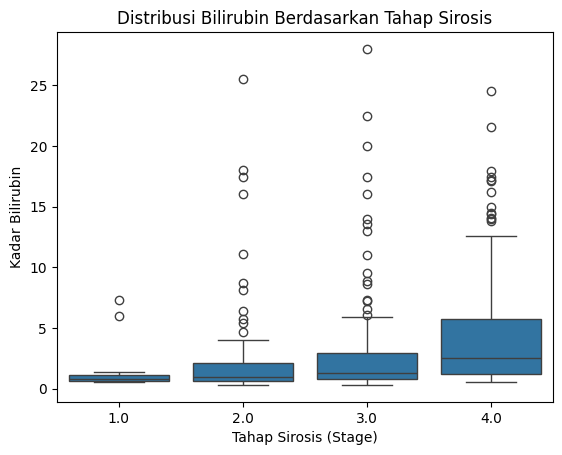

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

# Membuat boxplot untuk melihat distribusi 'Bilirubin' berdasarkan 'Stage'
sns.boxplot(x="Stage", y="Bilirubin", data=df)

# Menampilkan plot
plt.title("Distribusi Bilirubin Berdasarkan Tahap Sirosis")
plt.xlabel("Tahap Sirosis (Stage)")
plt.ylabel("Kadar Bilirubin")
plt.show()


### 4. **Eksplorasi Data**
Eksplorasi data bertujuan untuk memahami distribusi variabel, hubungan antar fitur, serta mendeteksi masalah seperti outliers atau missing values.

---
#### 1. Distribusi Data Numerik
Menggunakan Histogram untuk melihat sebaran nilai dari setiap fitur numerik.

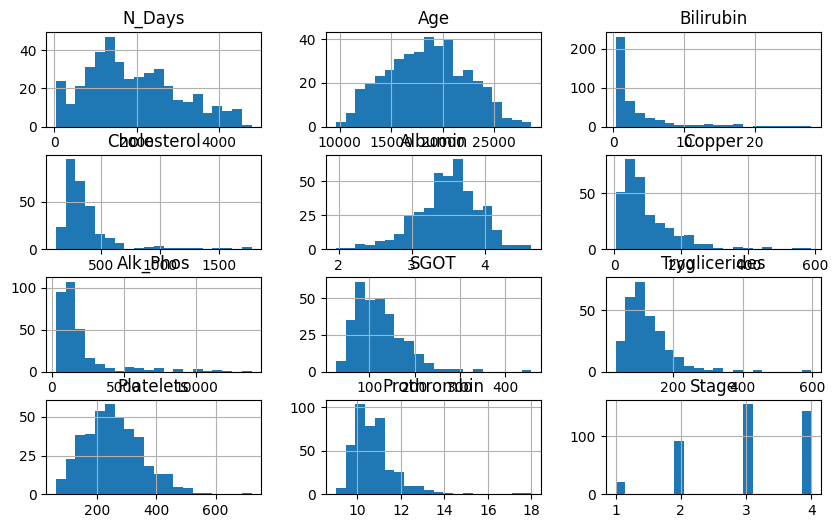

In [44]:
# Membuat histogram untuk semua kolom kecuali 'id'
# figsize=(10, 6) → Menentukan ukuran figure
# bins=20 → Membagi data ke dalam 20 interval
df.loc[:, df.columns != 'ID'].hist(figsize=(10, 6), bins=20)

# Menampilkan histogram
plt.show()



#### 2. Distribusi Data tiap kategori
Menggunakan box plot untuk melihat tiap kategori.

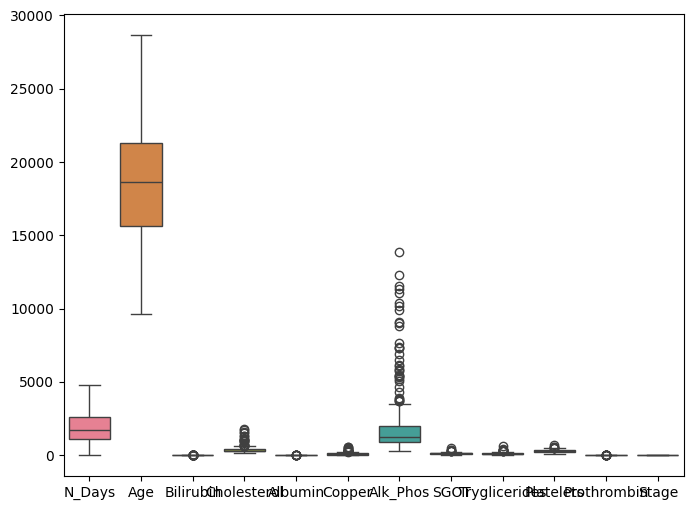

In [46]:
# Membuat figure dengan ukuran 8x6
plt.figure(figsize=(8,6))

# Membuat boxplot untuk melihat distribusi dan outlier pada semua fitur numerik
# Kolom 'id' dihapus karena tidak relevan dalam analisis
sns.boxplot(data=df.loc[:, df.columns != 'ID'])

# Menampilkan plot
plt.show()



#### 3. Hubungan Antar Variabel
Scatter plot membantu melihat hubungan antara dua variabel numerik.

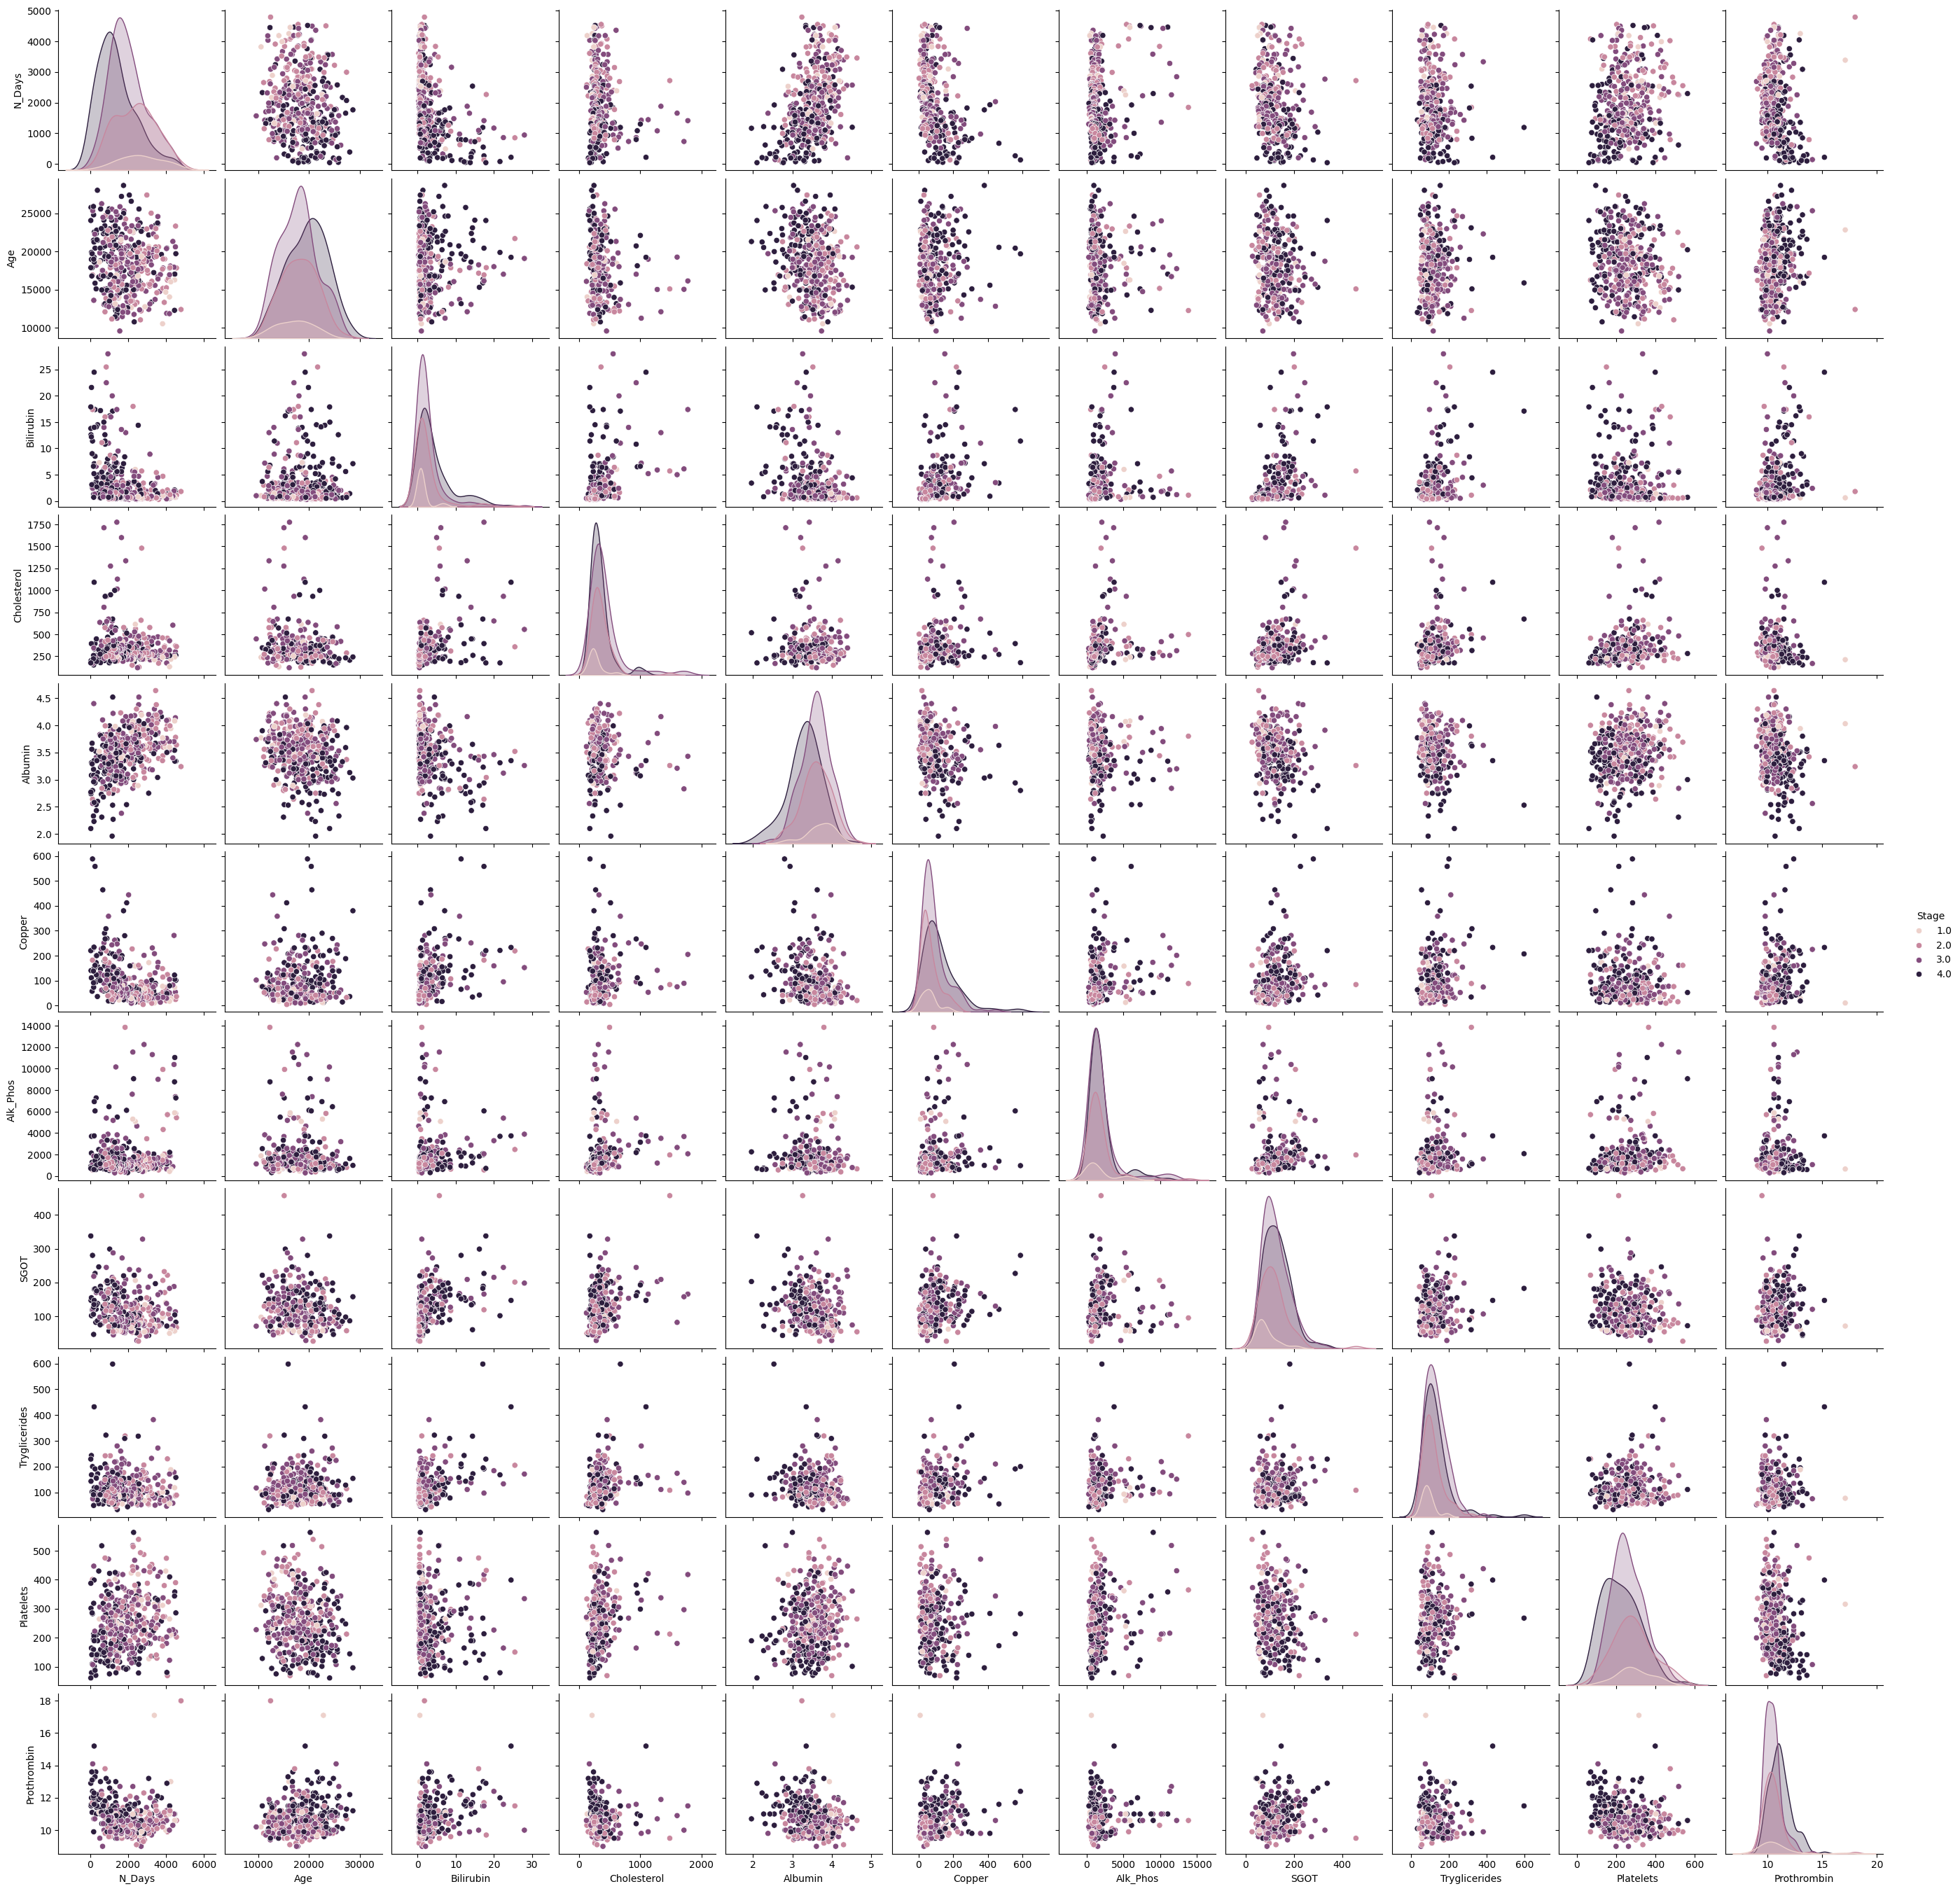

In [47]:
# Membuat pairplot antar fitur numerik berdasarkan kolom 'Stage'
sns.pairplot(df.drop(columns=['ID']), hue='Stage')

# Menampilkan plot
plt.show()

### 5. **Identifikasi masalah**
- deteksi missing value

In [48]:
# Mengecek jumlah missing value di setiap kolom
missing_values = df.isnull().sum()

# Menampilkan hasil jika ada missing value
print("Jumlah Missing Value per Kolom:\n", missing_values)


Jumlah Missing Value per Kolom:
 ID                   0
N_Days               0
Status               0
Drug               106
Age                  0
Sex                  0
Ascites            106
Hepatomegaly       106
Spiders            106
Edema                0
Bilirubin            0
Cholesterol        134
Albumin              0
Copper             108
Alk_Phos           106
SGOT               106
Tryglicerides      136
Platelets           11
Prothrombin          2
Stage                6
Bilirubin Level     75
dtype: int64


# **Preprocessing**

1. cek missing value, drop kolom tidak relevan, sisi missing value,dan normalisasi

In [49]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler

# 1. Cek missing values
print("Jumlah missing values:")
print(df.isnull().sum())

# 2. Drop kolom tidak relevan (misalnya ID)
df = df.drop(columns=['ID'])

# 3. Isi missing value numerik dengan median (lebih tahan outlier)
for col in df.select_dtypes(include=['float64', 'int64']).columns:
    df[col] = df[col].fillna(df[col].median())

# 4. Isi missing value kategorikal dengan modus (nilai terbanyak)
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].fillna(df[col].mode()[0])

# 5. Encode kolom kategorikal ke angka (Label Encoding)
le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])

# 6. (Opsional) Normalisasi fitur numerik
scaler = StandardScaler()
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

# 7. Dataset siap pakai
print("Dataset setelah preprocessing:")
print(df.head())


Jumlah missing values:
ID                   0
N_Days               0
Status               0
Drug               106
Age                  0
Sex                  0
Ascites            106
Hepatomegaly       106
Spiders            106
Edema                0
Bilirubin            0
Cholesterol        134
Albumin              0
Copper             108
Alk_Phos           106
SGOT               106
Tryglicerides      136
Platelets           11
Prothrombin          2
Stage                6
Bilirubin Level     75
dtype: int64
Dataset setelah preprocessing:
     N_Days    Status      Drug       Age       Sex   Ascites  Hepatomegaly  \
0 -1.375612  1.225441 -0.763763  0.768941 -0.342997  4.051749      0.755929   
1  2.340341 -0.869587 -0.763763  0.546706 -0.342997 -0.246807      0.755929   
2 -0.820938  1.225441 -0.763763  1.852567  2.915476 -0.246807     -1.322876   
3  0.006542  1.225441 -0.763763  0.383244 -0.342997 -0.246807      0.755929   
4 -0.375023  0.177927  1.309307 -1.210972 -0.342997 -0.



---

## 1. Missing Values

Beberapa kolom memiliki jumlah nilai yang hilang cukup signifikan. Misalnya:
- Kolom `Drug`, `Ascites`, `Hepatomegaly`, dan `Spiders` masing-masing memiliki 106 nilai hilang.
- Kolom `Cholesterol`, `Copper`, `Alk_Phos`, `SGOT`, dan `Tryglicerides` memiliki lebih dari 100 nilai hilang.
- Kolom `Stage` dan `Bilirubin Level` juga memiliki missing values, walau jumlahnya lebih sedikit.

Langkah penanganan:
- Kolom numerik seperti `Cholesterol`, `Platelets`, dan `Prothrombin` diisi menggunakan nilai median.
- Kolom kategorikal seperti `Drug`, `Stage`, dan `Bilirubin Level` diisi menggunakan nilai modus (nilai yang paling sering muncul).

---

## 2. Preprocessing

Setelah preprocessing, semua nilai di dataset telah berupa angka. Ini penting karena algoritma machine learning hanya dapat memproses data numerik. Selain itu, fitur numerik telah dinormalisasi menggunakan `StandardScaler`, yang membuat setiap fitur memiliki distribusi dengan rata-rata 0 dan standar deviasi 1. Ini bertujuan agar setiap fitur memiliki pengaruh yang seimbang terhadap model.

---

## 3. Encoding

Beberapa kolom bersifat kategorikal, contohnya:
- `Drug` (jenis obat)
- `Sex` (jenis kelamin)
- `Stage` (tahapan sirosis)
- `Bilirubin Level` (tingkat bilirubin)

Semua kolom tersebut diubah ke bentuk numerik menggunakan teknik encoding, misalnya One-Hot Encoding. Ini penting agar model dapat mengolah informasi kategorikal dengan benar.

---

## 4. Target Klasifikasi

Kolom `Status` dijadikan target (label) untuk klasifikasi. Nilai `1` menunjukkan pasien masih hidup, sedangkan `2` menunjukkan pasien meninggal. Tujuan model klasifikasi ini adalah memprediksi status akhir pasien berdasarkan fitur-fitur klinis yang tersedia.

---

## 5. Ringkasan Langkah

1. Menghapus kolom tidak relevan (`ID`)
2. Menangani nilai hilang pada fitur numerik dan kategorikal
3. Mengubah semua fitur menjadi numerik
4. Melakukan normalisasi data
5. Memisahkan fitur (`X`) dan target (`y`)
6. Melatih model klasifikasi dengan data training
7. Melakukan evaluasi terhadap model menggunakan metrik seperti akurasi, precision, recall, dan confusion matrix



# **Pemodelan (klasisfikasi : random forest)**

In [51]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# =========================
# 1. LOAD DATASET
# =========================
# Contoh load dari CSV
df = pd.read_csv('cirrhosis.csv')  # Ganti path jika perlu

# =========================
# 2. CEK & BERSIHKAN DATA
# =========================
# Drop kolom ID (tidak relevan)
df = df.drop(columns=['ID'])

# Tangani missing value numerik
for col in df.select_dtypes(include=['float64', 'int64']).columns:
    df[col] = df[col].fillna(df[col].median())

# Tangani missing value kategorikal
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].fillna(df[col].mode()[0])

# =========================
# 3. PISAHKAN FITUR & TARGET
# =========================
# Gunakan 'Status' sebagai target (1 = hidup, 2 = meninggal)
X = df.drop(columns=['Status'])
y = df['Status']

# Encode fitur kategorikal ke numerik (One-Hot Encoding)
X = pd.get_dummies(X, drop_first=True)

# =========================
# 4. NORMALISASI (Opsional)
# =========================
scaler = StandardScaler()
X[X.columns] = scaler.fit_transform(X)

# =========================
# 5. SPLIT DATA
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================
# 6. LATIH MODEL
# =========================
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# =========================
# 7. EVALUASI
# =========================
y_pred = model.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nAkurasi:")
print(accuracy_score(y_test, y_pred))


Confusion Matrix:
[[39  0  5]
 [ 3  0  1]
 [ 7  0 29]]

Classification Report:
              precision    recall  f1-score   support

           C       0.80      0.89      0.84        44
          CL       0.00      0.00      0.00         4
           D       0.83      0.81      0.82        36

    accuracy                           0.81        84
   macro avg       0.54      0.56      0.55        84
weighted avg       0.77      0.81      0.79        84


Akurasi:
0.8095238095238095


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))




## 1. **Confusion Matrix**

```
[[39  0  5]
 [ 3  0  1]
 [ 7  0 29]]
```

Confusion matrix menunjukkan seberapa baik model dalam memprediksi kelas yang berbeda (C, CL, D).

- **Baris pertama** (`C`):  
    - **39** benar diprediksi sebagai `C` (True Positive).
    - **5** salah diprediksi sebagai `D` (False Negative untuk `C`).
    - Tidak ada yang salah prediksi sebagai `CL`.
  
- **Baris kedua** (`CL`):  
    - **3** salah diprediksi sebagai `C` (False Positive untuk `CL`).
    - Tidak ada prediksi yang benar untuk `CL` (jadi **0** True Positive).
    - **1** salah diprediksi sebagai `D`.

- **Baris ketiga** (`D`):  
    - **7** salah diprediksi sebagai `C`.
    - Tidak ada yang salah diprediksi sebagai `CL`.
    - **29** benar diprediksi sebagai `D`.

---

## 2. **Classification Report**

**Classification Report** memberikan metrik evaluasi yang lebih mendalam, termasuk precision, recall, dan f1-score untuk setiap kelas.

### Kelas `C`:
- **Precision**: 0.80  
  - Artinya, dari semua prediksi yang model buat sebagai kelas `C`, 80% di antaranya benar-benar `C`.
  
- **Recall**: 0.89  
  - Artinya, dari semua data yang benar-benar `C`, 89% berhasil diprediksi dengan benar oleh model.
  
- **F1-Score**: 0.84  
  - Merupakan rata-rata harmonis dari precision dan recall. Nilai ini memberikan gambaran keseluruhan performa model untuk kelas `C`.

### Kelas `CL`:
- **Precision**: 0.00  
  - Model tidak memprediksi kelas `CL` dengan benar. Tidak ada prediksi `CL` yang benar (hanya prediksi `C` dan `D`).
  
- **Recall**: 0.00  
  - Dari semua data yang seharusnya kelas `CL`, model tidak berhasil memprediksi satu pun sebagai `CL`.
  
- **F1-Score**: 0.00  
  - Nilai ini menunjukkan performa yang sangat buruk untuk kelas `CL`, karena precision dan recall-nya 0.

### Kelas `D`:
- **Precision**: 0.83  
  - Artinya, dari semua prediksi yang model buat sebagai kelas `D`, 83% di antaranya benar-benar `D`.
  
- **Recall**: 0.81  
  - Artinya, dari semua data yang benar-benar `D`, 81% berhasil diprediksi dengan benar oleh model.
  
- **F1-Score**: 0.82  
  - Nilai ini menunjukkan keseimbangan yang baik antara precision dan recall untuk kelas `D`.

---

### 3. **Akurasi Model**

- **Akurasi**: 0.81 (81%)  
  - Artinya, model berhasil memprediksi kelas dengan benar sebanyak 81% dari total data yang ada. Meskipun terlihat baik secara keseluruhan, akurasi ini perlu dilihat lebih dalam dengan precision dan recall masing-masing kelas.

---

### 4. **Peringatan (Warning)**

- Peringatan yang muncul (`UndefinedMetricWarning`) menunjukkan bahwa untuk kelas `CL`, tidak ada data yang diprediksi sebagai `CL`, sehingga precision dan recall untuk kelas tersebut menjadi **0**. Model tidak dapat menangani kelas ini dengan baik.

---

### **Analisis**

- Model **cukup baik** dalam memprediksi kelas `C` dan `D`, dengan akurasi 80%-83%.
- Model **buruk** dalam memprediksi kelas `CL`, yang terlihat dari precision, recall, dan F1-score yang **0**.
- **Masalah** ini mungkin disebabkan oleh ketidakseimbangan data (kelas `CL` memiliki sedikit data atau tidak terdistribusi dengan baik).

---

